**INSTALLATIONS ET IMPORTATION**

In [1]:
!pip install -q timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.1 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision import models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.amp import GradScaler, autocast
import warnings
import random
from sklearn.model_selection import train_test_split
import timm
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from collections import Counter
from tqdm import tqdm
import optuna
from optuna.samplers import CmaEsSampler

**CHARGEMENT DES DONNÉES MNIST**

In [3]:
TRAIN_DIR = "/kaggle/input/datasets/ben519/mnist-as-png/mnist-png/train"
TEST_DIR  = "/kaggle/input/datasets/ben519/mnist-as-png/mnist-png/test"

In [4]:
def build_dataframe(root_dir):
    records = []
    for label in sorted(os.listdir(root_dir)):
        label_path = os.path.join(root_dir, label)
        if not os.path.isdir(label_path):
            continue
        for fname in os.listdir(label_path):
            if fname.lower().endswith(".png"):
                records.append({
                    "image_path": os.path.join(label_path, fname),
                    "class_id": int(label)
                })
    return pd.DataFrame(records)

train_full_df = build_dataframe(TRAIN_DIR)
test_df       = build_dataframe(TEST_DIR)

print(f"Train : {len(train_full_df)} images")
print(f"Test  : {len(test_df)} images")
train_full_df.head()

Train : 60000 images
Test  : 10000 images


,image_path,class_id
0,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0
1,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0
2,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0
3,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0
4,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0


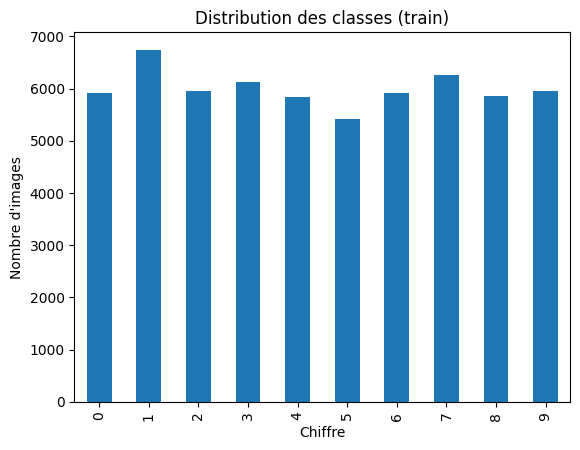

In [5]:
class_counts = train_full_df["class_id"].value_counts().sort_index()
class_counts.plot(kind="bar")
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes (train)")
plt.show()

**CONFIGURATIONS ET ENTRAÎNEMENT**

In [6]:
NUM_CLASSES    = 10
INPUT_SIZE     = 32
BATCH_SIZE     = 128
EPOCHS         = 40
PATIENCE       = 10
BASE_LR        = 2e-3
WD             = 1e-5
VAL_SPLIT      = 0.15

In [7]:
warnings.filterwarnings("ignore")

SEED = 1503
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU count:", torch.cuda.device_count())

Device: cuda
GPU count: 2


In [8]:
label_map = {i: str(i) for i in range(10)}
inv_label_map = {v: k for k, v in label_map.items()}

train_df, val_df = train_test_split(
    train_full_df,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=train_full_df["class_id"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train : {len(train_df)} | Val : {len(val_df)}")

Train : 51000 | Val : 9000


In [9]:
def apply_class_aware_geometry(image, **kwargs):
    label = kwargs.get("label", None)
    if label is None:
        return image
        
    if label in [6, 9]:
        geo = A.Compose([
            A.Affine(scale=(0.9, 1.1), rotate=(-10, 10), shear=(-3, 3), p=0.5),
            A.ThinPlateSpline(scale_range=[0.01, 0.03], num_control_points=4, p=0.2)
        ])
    elif label in [2, 5]:
        geo = A.Compose([
            A.Affine(scale=(0.8, 1.2), rotate=(-12, 12), shear=(-5, 5), p=0.5),
            A.ThinPlateSpline(scale_range=[0.02, 0.04], num_control_points=4, p=0.3)
        ])
    elif label in [0, 1, 8]:
        geo = A.Compose([
            A.Affine(scale=(0.8, 1.2), rotate=(-180, 180), shear=(-15, 15), p=0.7),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5)
        ])
    else:
        geo = A.Compose([
            A.Affine(scale=(0.8, 1.2), rotate=(-30, 30), shear=(-10, 10), p=0.5),
            A.ThinPlateSpline(scale_range=[0.04, 0.06], num_control_points=4, p=0.4)
        ])
        
    return geo(image=image)["image"]
    

train_transform = A.Compose([
    A.Resize(height=INPUT_SIZE, width=INPUT_SIZE),
    
    A.Lambda(image=apply_class_aware_geometry, p=1.0),
    
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
    ], p=0.3),
    
    A.Normalize(mean=[0.1307], std=[0.3081]),
    ToTensorV2(),
], seed=SEED)

val_transform = A.Compose([
    A.Resize(height=INPUT_SIZE, width=INPUT_SIZE),
    A.Normalize(mean=[0.1307], std=[0.3081]),
    ToTensorV2(),
])

In [10]:
class MNISTDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("L")
        img_np = np.array(img)
        
        label = int(row["class_id"])

        if self.transform:
            img_np = self.transform(image=img_np, label=label)["image"]

        if self.is_test:
            return img_np, label, row["image_path"]
        return img_np, label

In [11]:
def prepareDataLoaders(train_df, val_df):
    class_counts_series = train_df["class_id"].value_counts()
    weights_map = 1.0 / class_counts_series
    weights_map = weights_map / weights_map.sum() * NUM_CLASSES
    class_weights = torch.tensor(
        [weights_map[i] for i in range(NUM_CLASSES)], dtype=torch.float32
    )

    train_dataset = MNISTDataset(df=train_df, transform=train_transform)
    val_dataset   = MNISTDataset(df=val_df,   transform=val_transform)

    sample_weights = [class_weights[t] for t in train_dataset.df["class_id"].values]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        num_workers=4,
        pin_memory=True,
        sampler=sampler,
        prefetch_factor=2,
        drop_last=True,
        persistent_workers=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        prefetch_factor=2,
        persistent_workers=True
    )

    print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)}")
    return train_loader, val_loader

In [12]:
class MNISTClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # --- BACKBONE CNN NATIF ---
        # Conçu pour des entrées de taille [Batch, 1, 32, 32]
        self.backbone = nn.Sequential(
            # Bloc Conv 1 : 32x32x1 -> 32x32x32 -> 16x16x32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),

            # Bloc Conv 2 : 16x16x32 -> 16x16x64 -> 8x8x64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3),

            # Bloc Conv 3 : 8x8x64 -> 8x8x128 -> 6x6x128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=0), # padding=0 réduit de 8x8 à 6x6
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Dropout2d(0.4),
            
            # Mise à plat automatique 
            nn.Flatten(start_dim=1)
        )

        num_features = 128 * 6 * 6

        #  TÊTE DE CLASSIFICATION ---
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, image):
        # image attendue : [Batch_Size, 1, 32, 32]
        x = self.backbone(image)
        return self.classifier(x)


In [13]:
def prepareModel():
    model = MNISTClassifier( num_classes=NUM_CLASSES)
    model = model.to(device)
    print(f"MNISTClassifier pret pour l'entrainement sur {device}")
    return model

In [14]:
def load_trained_model(checkpoint_path):
    model = MNISTClassifier(num_classes=NUM_CLASSES)
    device_ = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")

    state_dict = torch.load(checkpoint_path, map_location=device_)
    if "model_state_dict" in state_dict:
        state_dict = state_dict["model_state_dict"]

    model.load_state_dict(state_dict)
    print(f"Modele charge depuis {checkpoint_path}")
    model = model.to(device_)
    model.eval()
    return model


In [15]:
def get_parameter_groups(model, base_lr, weight_decay=1e-4):
    parameter_groups = []
    decay_params = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if len(param.shape) == 1 or name.endswith(".bias"):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    parameter_groups.append({
        "params": decay_params,
        "lr": base_lr,
        "weight_decay": weight_decay
    })
    parameter_groups.append({
        "params": no_decay_params,
        "lr": base_lr,
        "weight_decay": 0.0
    })

    return parameter_groups


In [16]:
def train_epoch(model, train_loader, val_loader, epochs, patience, fold):
    print("Configurations ....")
    criterion = nn.CrossEntropyLoss(label_smoothing=0.02)

    for param in model.parameters():
        param.requires_grad = True

    param_groups = get_parameter_groups(model, base_lr=BASE_LR)
    optimizer = optim.AdamW(param_groups, weight_decay=WD)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)
    scaler = torch.amp.GradScaler("cuda")

    print("Debut de l'entrainement")

    epoch_times = []
    train_errors = []
    val_errors = []
    best_f1 = 0.0
    epoch_counter = 0

    start_event = torch.cuda.Event(enable_timing=True)
    end_event   = torch.cuda.Event(enable_timing=True)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_event.record()

        for inputs, labels in train_loader:
            optimizer.zero_grad(set_to_none=True)
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        model.eval()
        val_preds, val_labels_list = [], []
        val_loss = 0.0

        with torch.no_grad(), torch.amp.autocast("cuda"):
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(inputs)
                preds   = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())
                val_loss += criterion(outputs, labels).item()

        f1       = f1_score(val_labels_list, val_preds, average="macro")
        accuracy = accuracy_score(val_labels_list, val_preds)
        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss   = val_loss    / len(val_loader)
        train_errors.append(avg_train_loss)
        val_errors.append(avg_val_loss)

        scheduler.step()

        end_event.record()
        torch.cuda.synchronize()
        epoch_time = start_event.elapsed_time(end_event) / 1000
        epoch_times.append(epoch_time)
        avg_time      = sum(epoch_times) / len(epoch_times)
        remaining_est = avg_time * (epochs - (epoch + 1))

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Temps : {epoch_time/60:.2f} min | Restant : {remaining_est/60:.1f} min")
        print(f"Loss -> Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")
        print(f"Metrics -> Accuracy: {accuracy:.4f} | F1-Macro: {f1:.4f}")

        if epoch % 4 == 0 or epoch == epochs - 1:
            print("Detail par classe :")
            print(classification_report(val_labels_list, val_preds, target_names=[str(i) for i in range(NUM_CLASSES)]))

        if f1 > best_f1:
            best_f1 = f1
            epoch_counter = 0
            torch.save(model.state_dict(), f"best_model_{fold+1}.pth")
        else:
            epoch_counter += 1
            print(f"Pas d'amelioration depuis {epoch_counter} epoques")
            if epoch_counter >= patience:
                print(f"Early stopping a l'epoque {epoch+1}")
                print(classification_report(val_labels_list, val_preds, target_names=[str(i) for i in range(NUM_CLASSES)]))
                break

    print("Entrainement termine. Meilleur F1 :", best_f1)
    return best_f1, train_errors, val_errors


In [23]:
def plot_training_losses(train_errors, val_errors):
    epochs_range = range(1, len(train_errors) + 1)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    
    ax.plot(epochs_range, train_errors, label="Train Loss", color="#1f77b4", linewidth=2.5, marker='o', markersize=4, alpha=0.8)
    ax.plot(epochs_range, val_errors, label="Val Loss", color="#ff7f0e", linewidth=2.5, marker='s', markersize=4, alpha=0.8)
    
    ax.set_title("Model Loss Optimization History", fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
    ax.set_xlabel("Epochs", fontsize=11, fontweight='semibold', labelpad=8)
    ax.set_ylabel("Loss Value", fontsize=11, fontweight='semibold', labelpad=8)
    
    ax.set_xlim(1, len(train_errors))
    ax.grid(True, linestyle="--", alpha=0.5, color='#cccccc')
    
    ax.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e2e8f0', shadow=False, fontsize=10)
    
    plt.tight_layout()
    plt.show()
    plt.style.use('default')



In [18]:
def evaluate_model(model, val_loader, fold, title="Matrice de Confusion"):
    model.eval()
    val_preds, val_labels_list = [], []
    error_records = []

    with torch.no_grad(), torch.amp.autocast("cuda"):
        for inputs, labels in val_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            preds   = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

            preds_cpu  = preds.cpu().numpy()
            labels_cpu = labels.cpu().numpy()
            mask = (preds_cpu != labels_cpu)
            for i in range(len(mask)):
                if mask[i]:
                    error_records.append({
                        "true_class": labels_cpu[i],
                        "pred_class": preds_cpu[i],
                    })

    conf_matrix = confusion_matrix(val_labels_list, val_preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix,
        display_labels=[str(i) for i in range(NUM_CLASSES)]
    )
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title(title)
    plt.show()

    f1 = f1_score(val_labels_list, val_preds, average="macro")
    print(f"F1 macro final : {f1:.4f}")

    if error_records:
        df_errors = pd.DataFrame(error_records)
        df_errors.to_csv(f"val_{fold+1}_false_analysis.csv", index=False)
        print(f"{len(df_errors)} fausses predictions sauvegardees")
        return df_errors
    return None

In [19]:
train_dl, val_dl = prepareDataLoaders(train_df, val_df)

Train : 51000 | Val : 9000


In [20]:
try:
    images, labels = next(iter(train_dl))
    print("DataLoader fonctionnel !")
    print(f"Tenseur Images  : Shape {list(images.shape)}")
    print(f"Tenseur Labels  : Shape {list(labels.shape)}")
except Exception as e:
    print(f"Erreur lors du chargement du batch : {e}")

DataLoader fonctionnel !
Tenseur Images  : Shape [128, 1, 32, 32]
Tenseur Labels  : Shape [128]


In [21]:
model = prepareModel()

print("=== Entrainement du modele ===")

best_f1, train_errors, val_errors = train_epoch(
    model=model,
    train_loader=train_dl,
    val_loader=val_dl,
    epochs=EPOCHS,
    patience=PATIENCE,
    fold=0,
)
plot_training_losses(train_errors,val_errors)

del train_dl

best_model = load_trained_model("/kaggle/working/best_model_1.pth")
evaluate_model(best_model, val_dl, fold=0, title="Matrice de confusion")

MNISTClassifier pret pour l'entrainement sur cuda
=== Entrainement du modele ===
Configurations ....
Debut de l'entrainement
Epoch 1/40
Temps : 0.98 min | Restant : 38.3 min
Loss -> Train: 0.3144 | Val: 0.2418
Metrics -> Accuracy: 0.9841 | F1-Macro: 0.9840
Detail par classe :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       888
           1       0.99      0.99      0.99      1011
           2       0.99      0.97      0.98       894
           3       0.99      0.97      0.98       920
           4       1.00      0.97      0.98       876
           5       0.98      0.99      0.99       813
           6       0.99      1.00      0.99       888
           7       0.97      0.99      0.98       940
           8       0.97      0.98      0.98       878
           9       0.96      0.99      0.97       892

    accuracy                           0.98      9000
   macro avg       0.98      0.98      0.98      9000
weighted avg       

NameError: name 'FREEZE_EPOCHS' is not defined

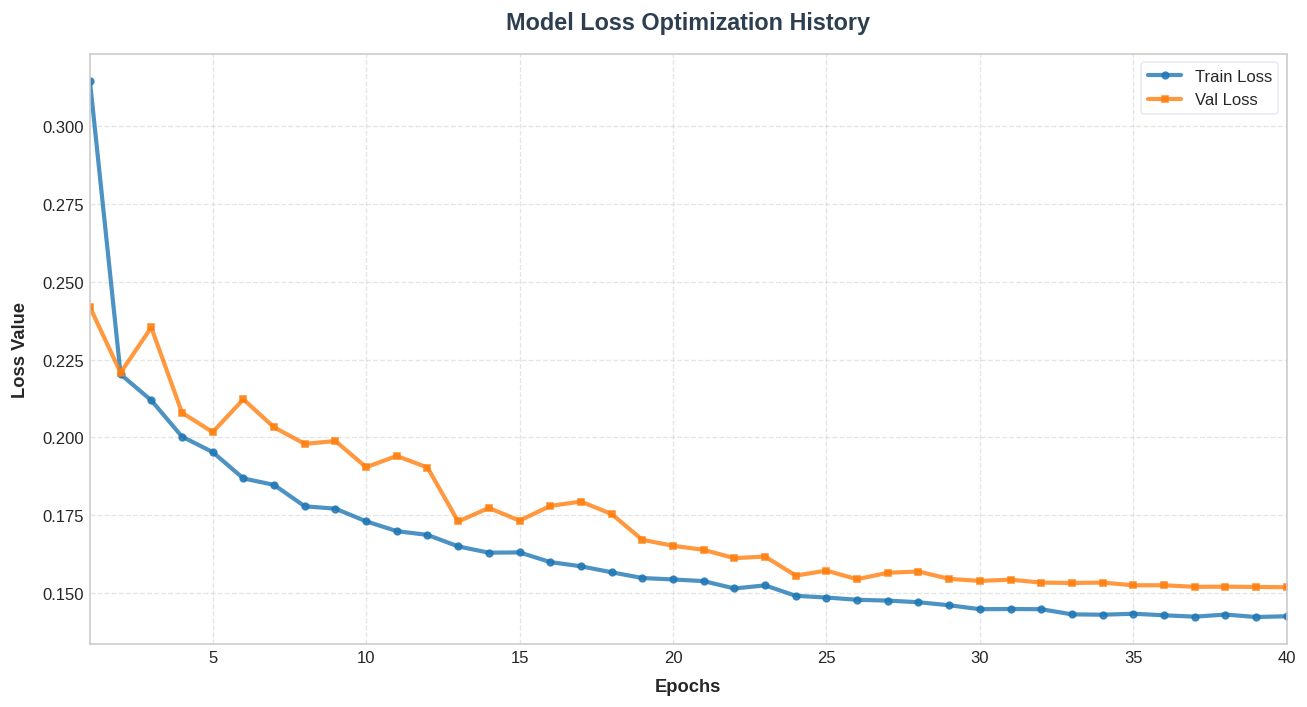

Modele charge depuis /kaggle/working/best_model_1.pth


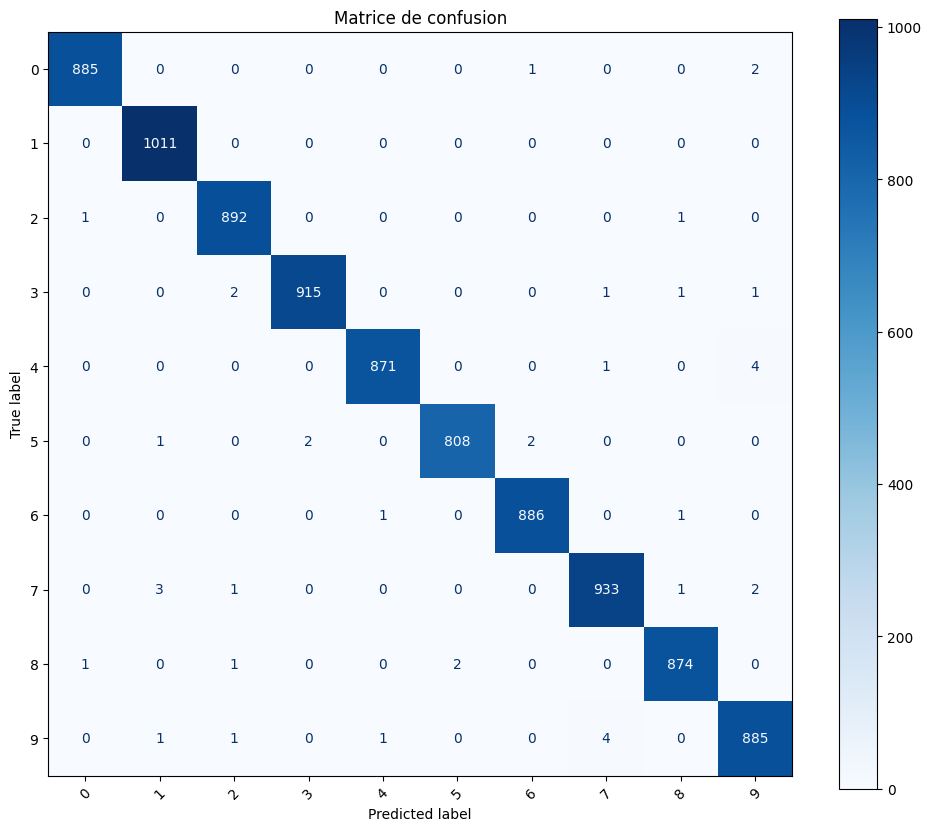

F1 macro final : 0.9955
40 fausses predictions sauvegardees


,true_class,pred_class
0,3,7
1,5,3
2,2,8
3,4,9
4,3,2
5,0,9
6,4,9
7,2,0
8,7,8
9,7,1


In [27]:
plot_training_losses(train_errors,val_errors)

best_model = load_trained_model("/kaggle/working/best_model_1.pth")
evaluate_model(best_model, val_dl, fold=0, title="Matrice de confusion")

In [28]:
test_dataset = MNISTDataset(df=test_df, transform=val_transform, is_test=True)
test_loader  = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)
print("Test :", len(test_dataset))

Test : 10000


In [32]:
best_model.eval()
predictions = []

with torch.no_grad(), torch.amp.autocast("cuda"):
    for inputs, labels, paths in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        outputs = best_model(inputs)
        preds   = torch.argmax(outputs, dim=1).cpu().numpy()
        for path, pred, true in zip(paths, preds, labels.numpy()):
            predictions.append({
                "image_path": path,
                "true_class": int(true),
                "pred_class":  int(pred)
            })

predictions_df = pd.DataFrame(predictions)
predictions_df.to_csv("results.csv", index=False)
print(f"Inference terminee : {len(predictions_df)} lignes sauvegardees.")

Inference terminee : 10000 lignes sauvegardees.


In [33]:
f1_test  = f1_score(predictions_df["true_class"], predictions_df["pred_class"], average="macro")
acc_test = accuracy_score(predictions_df["true_class"], predictions_df["pred_class"])
print(f"Test F1-Macro : {f1_test:.4f}")
print(f"Test Accuracy : {acc_test:.4f}")
predictions_df.head(10)

Test F1-Macro : 0.9965
Test Accuracy : 0.9965


,image_path,true_class,pred_class
0,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
1,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
2,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
3,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
4,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
5,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
6,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
7,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
8,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0
9,/kaggle/input/datasets/ben519/mnist-as-png/mni...,0,0


In [34]:
print("Fin de la partie")

Fin de la partie
